In [32]:
import pandas as pd
import numpy as np
import importlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import irina.utility_functions as uf

In [87]:
year = 2023
mode = "individual_"
mode_ = "collaborative_"

In [88]:
df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year}.csv", index_col=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_cs_ = pd.read_csv(uf.PATH+f"df_country_subfield/{mode_}{year}.csv", index_col=0)
df_prob_ = df_cs_.div(df_cs_.sum(axis=1), axis=0)

In [89]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [90]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [91]:
df_dist = uf.get_w1_distances(subfield_tree, df_prob)
np.fill_diagonal(df_dist.values, np.nan)
df_dist_ = uf.get_w1_distances(subfield_tree, df_prob_)
np.fill_diagonal(df_dist_.values, np.nan)

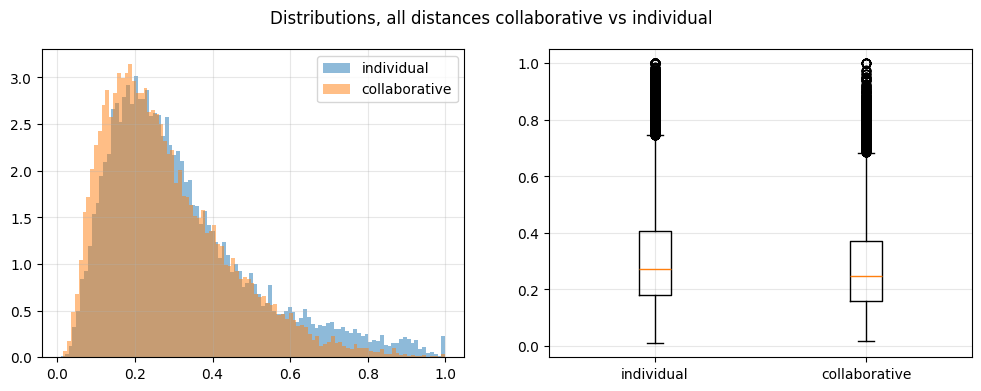

In [92]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

ax1.hist(df_dist.values.flatten(), bins=100, alpha=0.5, label=mode[:-1], density=True)
ax1.hist(df_dist_.values.flatten(), bins=100, alpha=0.5, label=mode_[:-1], density=True)
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)
data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]
data2 = df_dist_.values.flatten()
data2 = data2[~np.isnan(data2)]
ax2.boxplot([data1, data2])
ax2.set_xticks([1, 2], [mode[:-1], mode_[:-1]])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

In [93]:
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
y_labels = df_dist.index.to_list()
uf.plotly_heatmap(
    df_dist.loc[y_labels],
    x_labels=df_dist.columns,
    y_labels=y_labels,
    z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {mode[:-1]}, {year}",
)

In [94]:
df_dist.values.shape

(216, 216)

In [96]:
# Example: distance matrix (symmetric, zeros on diagonal)
D = df_dist.fillna(0).values

# Convert to condensed form (required by linkage)
condensed_D = squareform(D)

# Perform hierarchical clustering
# method can be: 'single', 'complete', 'average', 'ward'
Z = linkage(condensed_D, method='average')


In [112]:
# Assign clusters by specifying a max distance threshold
labels = fcluster(Z, t=0.2, criterion='distance')
order = np.argsort(labels)
# print("Cluster labels:", labels)

In [113]:
labels = np.array(labels)

order = np.argsort(labels)
D_ordered = D[np.ix_(order, order)]

names = df_dist.index.to_numpy()
names_ordered = [uf.id2name_country[name] for name in names[order]]
labels_ordered = labels[order]

In [114]:
fig = go.Figure(
    data=go.Heatmap(
        z=D_ordered,
        x=names_ordered,
        y=names_ordered,
        colorscale="Viridis",
        colorbar=dict(title="Distance"),
        hovertemplate="Row: %{y}<br>Col: %{x}<br>Dist: %{z:.3f}<extra></extra>"
    )
)

fig.update_layout(
    title="Distance matrix reordered by cluster labels",
    xaxis=dict(
        tickangle=45,
        tickfont=dict(size=8),
        automargin=True
    ),
    yaxis=dict(
        tickfont=dict(size=8),
        automargin=True
    ),
    width=900,
    height=900
)
# cluster boundaries
changes = np.where(np.diff(labels_ordered) != 0)[0] + 1

for c in changes:
    fig.add_shape(
        type="line",
        x0=-0.5, x1=len(names_ordered)-0.5,
        y0=c-0.5, y1=c-0.5,
        line=dict(color="white", width=1)
    )
    fig.add_shape(
        type="line",
        x0=c-0.5, x1=c-0.5,
        y0=-0.5, y1=len(names_ordered)-0.5,
        line=dict(color="white", width=1)
    )

fig.show()


In [115]:
df_map = (
    df_dist
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    [["alpha-2", "alpha-3", "name", "sub-region", "region"]]
    .assign(cluster=labels,
            cluster_str = lambda df: df["cluster"].astype(str))
    .rename(columns={"alpha-3": "country", "alpha-2": "country2"})
)
df_map.sample(5)

,country2,country,name,sub-region,region,cluster,cluster_str
100,HK,HKG,Hong Kong,Eastern Asia,Asia,14,14
216,SY,SYR,Syrian Arab Republic,Western Asia,Asia,3,3
188,LC,LCA,Saint Lucia,Latin America and the Caribbean,Americas,15,15
53,CR,CRI,Costa Rica,Latin America and the Caribbean,Americas,12,12
209,ES,ESP,Spain,Southern Europe,Europe,14,14


In [116]:
fig = px.choropleth(
    df_map,
    locations="country",
    color="cluster_str",               # use the categorical version
    locationmode="ISO-3",
    color_discrete_sequence=px.colors.qualitative.Set3,  # discrete color palette
    title=f"Country clusters based on distance matrix, {mode[:-1]}, {year}"
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type="natural earth"
    ),
    height=600,
)

fig.show()